In [2]:
import glob as glob
import json
import os
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from itertools import combinations
import numpy as np

# utils functions

In [3]:
def load_df(folder_path, benchmark_name):
    paths = glob.glob(os.path.join(folder_path, f"{benchmark_name}_*.json"))
    df = pd.DataFrame()
    for path in paths:
        with open(path, "r") as f:
            data = json.load(f)
            row = data
            df = pd.concat([df, pd.DataFrame([row])], ignore_index=True)
            df["features"] = df["features"].apply(lambda x: ",".join(x) if isinstance(x, list) else x)
    return df

In [4]:
def show_table(folder_path, benchmark):
    df = load_df(folder_path, benchmark)
    grouped = df.groupby(['method', 'alpha'])[['query', 'ask', 'ask_req', 'yes', 'no']]
    
    mean_df = grouped.mean()
    std_df = grouped.std()
    
    result = mean_df.copy()
    for col in mean_df.columns:
        result[col] = mean_df[col].map(lambda m: f"{m:.1f}") + " ± " + std_df[col].map(lambda s: f"{s:.1f}")
    result=result.reindex(["quacq", "pquacq", "ml_quacq_e", "ml_quacq_n"], level='method')
    return result

# Overall analysis

In [5]:
folder_path = "../../results/alpha_effect"
results_all=load_df(folder_path, "*")

In [6]:
overall=results_all[(results_all['alpha']==4) | (results_all['method']=='quacq')]

mean_overall=overall.pivot_table(index='method', columns='benchmark', values='query', aggfunc='mean')
std_overall=overall.pivot_table(index='method', columns='benchmark', values='query', aggfunc='std')

result_overall = mean_overall.copy()
for col in mean_overall.columns:
    result_overall[col] = mean_overall[col].map(lambda m: f"{m:.1f}") + " ± " + std_overall[col].map(lambda s: f"{s:.1f}")
result_overall=result_overall.reindex(["quacq", "pquacq", "ml_quacq_e", "ml_quacq_n"], level='method')

result_overall

benchmark,jigsaw,random,rflap,zebra
method,,,,
quacq,1921.9 ± 44.7,325.5 ± 35.6,1138.1 ± 33.1,602.7 ± 22.3
pquacq,1158.6 ± 51.2,344.9 ± 35.6,1063.1 ± 32.4,428.4 ± 15.6
ml_quacq_e,842.2 ± 104.2,356.9 ± 51.1,705.7 ± 28.4,492.0 ± 17.3
ml_quacq_n,746.8 ± 39.9,351.4 ± 44.1,607.4 ± 54.5,393.3 ± 49.7


# alpha effect analysis

In [8]:
folder_path = "../../results/alpha_effect"
method="jigsaw"

print(f"Results for {method}:")
show_table(folder_path, method)

Results for jigsaw:


query            ask       ask_req           yes  \
method     alpha                                                              
quacq      1       1921.9 ± 44.7  1921.9 ± 44.7     0.0 ± 0.0     0.0 ± 0.0   
pquacq     1       1469.6 ± 53.6  1263.0 ± 52.8   206.6 ± 3.3    94.6 ± 4.1   
           2       1321.4 ± 46.9  1010.0 ± 43.4   311.4 ± 5.8   123.2 ± 4.0   
           3       1228.5 ± 40.9   853.1 ± 37.3   375.4 ± 9.8   139.6 ± 3.7   
           4       1158.6 ± 51.2   741.4 ± 42.5  417.2 ± 12.6   150.8 ± 4.2   
           5       1111.3 ± 29.7   668.2 ± 27.6  443.0 ± 11.2   157.4 ± 3.5   
ml_quacq_e 1      1241.2 ± 144.3  980.0 ± 177.0  261.3 ± 37.6  115.4 ± 18.9   
           2       968.2 ± 175.5  513.5 ± 248.6  454.7 ± 80.9  164.2 ± 27.2   
           3       923.2 ± 126.4  426.4 ± 179.4  496.8 ± 60.2  174.5 ± 19.6   
           4       842.2 ± 104.2  304.0 ± 147.5  538.3 ± 50.9  187.5 ± 16.2   
           5        801.1 ± 99.0  234.3 ± 140.9  566.8 ± 42.9  195.1 ± 14.8   
ml_quacq_n 1      1078.9 ± 101.4  820.6 ± 134.5  258.2 ± 39.4  129.4 ± 15.5   
           2        826.7 ± 67.5  373.8 ± 100.2  452.9 ± 51.0  178.6 ± 10.8   
           3        766.7 ± 53.6   239.3 ± 75.6  527.5 ± 48.3   193.5 ± 7.8   
           4        746.8 ± 39.9   192.8 ± 43.7  553.9 ± 42.0   198.2 ± 5.5   
           5        741.7 ± 36.4   173.2 ± 44.2  568.5 ± 28.5   201.2 ± 4.2   

                            no  
method     alpha                
quacq      1         0.0 ± 0.0  
pquacq     1       112.0 ± 4.2  
           2       188.2 ± 7.8  
           3       235.8 ± 9.8  
           4      266.3 ± 14.2  
           5      285.7 ± 10.8  
ml_quacq_e 1      145.9 ± 20.3  
           2      290.6 ± 55.8  
           3      322.3 ± 42.3  
           4      350.8 ± 36.9  
           5      371.7 ± 28.5  
ml_quacq_n 1      128.8 ± 26.1  
           2      274.3 ± 42.3  
           3      334.0 ± 41.8  
           4      355.7 ± 37.9  
           5      367.3 ± 25.7

In [9]:
method="zebra"

print(f"Results for {method}:")
show_table(folder_path, method)

Results for zebra:


query           ask       ask_req         yes  \
method     alpha                                                         
quacq      1      602.7 ± 22.3  602.7 ± 22.3     0.0 ± 0.0   0.0 ± 0.0   
pquacq     1      431.8 ± 18.1  394.7 ± 16.6    37.1 ± 3.4  29.4 ± 0.8   
           2      427.6 ± 15.9  388.8 ± 14.5    38.8 ± 4.2  30.0 ± 0.0   
           3      428.0 ± 15.7  389.2 ± 14.1    38.9 ± 4.3  30.0 ± 0.0   
           4      428.4 ± 15.6  389.4 ± 14.0    39.0 ± 4.4  30.0 ± 0.0   
           5      428.5 ± 15.6  389.4 ± 14.0    39.1 ± 4.4  30.0 ± 0.0   
ml_quacq_e 1      413.7 ± 33.2  337.2 ± 36.1    76.5 ± 3.3  34.1 ± 3.1   
           2      429.7 ± 31.8  305.1 ± 35.5   124.6 ± 4.8  36.7 ± 3.3   
           3      456.9 ± 26.3  283.5 ± 29.3   173.5 ± 6.3  38.8 ± 2.5   
           4      492.0 ± 17.3  269.5 ± 20.1   222.5 ± 7.8  39.6 ± 1.2   
           5      512.9 ± 19.0  266.1 ± 18.3  246.8 ± 10.0  40.0 ± 1.1   
ml_quacq_n 1      375.5 ± 25.4  313.3 ± 25.6    62.2 ± 8.0  36.2 ± 2.3   
           2      370.9 ± 31.2  293.3 ± 26.3   77.7 ± 14.4  38.1 ± 2.1   
           3      383.6 ± 38.0  286.2 ± 20.1   97.4 ± 29.4  38.5 ± 1.8   
           4      393.3 ± 49.7  276.5 ± 17.1  116.7 ± 47.6  39.3 ± 1.4   
           5      409.4 ± 61.4  275.7 ± 20.5  133.7 ± 58.5  39.4 ± 1.5   

                            no  
method     alpha                
quacq      1         0.0 ± 0.0  
pquacq     1         7.7 ± 3.7  
           2         8.8 ± 4.2  
           3         8.9 ± 4.3  
           4         9.0 ± 4.4  
           5         9.1 ± 4.4  
ml_quacq_e 1        42.5 ± 0.9  
           2        87.9 ± 2.4  
           3       134.7 ± 5.0  
           4       182.9 ± 7.1  
           5      206.8 ± 10.0  
ml_quacq_n 1        26.0 ± 7.8  
           2       39.6 ± 14.6  
           3       58.9 ± 29.8  
           4       77.5 ± 47.9  
           5       94.3 ± 59.0

In [10]:
method="random"

print(f"Results for {method}:")
show_table(folder_path, method)

Results for random:


query           ask      ask_req        yes  \
method     alpha                                                       
quacq      1      325.5 ± 35.6  325.5 ± 35.6    0.0 ± 0.0  0.0 ± 0.0   
pquacq     1      341.6 ± 37.5  325.0 ± 35.1   16.6 ± 4.1  0.6 ± 0.8   
           2      344.7 ± 37.7  324.9 ± 34.4   19.8 ± 5.6  0.6 ± 0.7   
           3      345.1 ± 35.8  324.7 ± 32.8   20.4 ± 5.7  0.6 ± 0.8   
           4      344.9 ± 35.6  324.5 ± 32.6   20.4 ± 5.7  0.6 ± 0.8   
           5      344.9 ± 35.6  324.4 ± 32.6   20.5 ± 5.9  0.6 ± 0.8   
ml_quacq_e 1      333.3 ± 38.0  325.0 ± 34.2    8.3 ± 4.8  0.2 ± 0.5   
           2      341.5 ± 42.7  323.4 ± 34.5  18.1 ± 10.9  1.0 ± 1.2   
           3      348.4 ± 45.4  320.3 ± 32.8  28.0 ± 16.2  1.5 ± 1.5   
           4      356.9 ± 51.1  317.8 ± 34.1  39.1 ± 23.0  2.2 ± 2.5   
           5      366.2 ± 54.9  315.9 ± 33.1  50.3 ± 28.4  2.7 ± 2.2   
ml_quacq_n 1      331.4 ± 36.5  323.1 ± 32.8    8.3 ± 4.7  0.4 ± 0.7   
           2      338.6 ± 40.6  321.0 ± 31.6  17.7 ± 10.6  0.9 ± 1.3   
           3      346.0 ± 42.5  320.3 ± 31.4  25.7 ± 14.6  1.0 ± 1.3   
           4      351.4 ± 44.1  315.3 ± 28.8  36.1 ± 20.4  1.8 ± 1.8   
           5      360.7 ± 54.5  313.6 ± 32.4  47.1 ± 28.2  2.4 ± 2.3   

                           no  
method     alpha               
quacq      1        0.0 ± 0.0  
pquacq     1       16.0 ± 4.1  
           2       19.2 ± 5.6  
           3       19.7 ± 5.7  
           4       19.8 ± 5.8  
           5       19.9 ± 5.9  
ml_quacq_e 1        8.0 ± 4.6  
           2      17.1 ± 10.1  
           3      26.6 ± 15.0  
           4      36.9 ± 21.0  
           5      47.7 ± 26.6  
ml_quacq_n 1        7.9 ± 4.3  
           2       16.8 ± 9.8  
           3      24.7 ± 13.7  
           4      34.3 ± 19.0  
           5      44.7 ± 26.2

In [11]:
method="rflap"

print(f"Results for {method}:")
show_table(folder_path, method)

Results for rflap:


query            ask       ask_req          yes  \
method     alpha                                                            
quacq      1      1138.1 ± 33.1  1138.1 ± 33.1     0.0 ± 0.0    0.0 ± 0.0   
pquacq     1      1108.2 ± 37.0   990.8 ± 35.1   117.3 ± 9.0   23.5 ± 2.2   
           2      1070.2 ± 36.2   923.5 ± 35.8  146.7 ± 10.5   31.8 ± 2.3   
           3      1068.5 ± 26.6   912.1 ± 26.0  156.4 ± 10.8   33.8 ± 1.6   
           4      1063.1 ± 32.4   906.7 ± 31.5   156.4 ± 9.7   33.8 ± 1.6   
           5      1066.3 ± 42.8   908.4 ± 42.5  157.9 ± 12.0   34.1 ± 1.8   
ml_quacq_e 1       633.6 ± 50.1   437.4 ± 52.7   196.2 ± 3.5   82.8 ± 4.5   
           2       660.7 ± 47.5   337.8 ± 54.7   322.9 ± 9.1   92.8 ± 5.0   
           3       689.3 ± 35.7   260.2 ± 43.0  429.1 ± 16.4   99.6 ± 3.7   
           4       705.7 ± 28.4   212.9 ± 38.7  492.8 ± 17.1  103.9 ± 3.7   
           5       720.4 ± 21.1   195.9 ± 24.9  524.5 ± 13.3  105.5 ± 2.2   
ml_quacq_n 1       527.6 ± 48.1   332.8 ± 50.5   194.8 ± 8.5   92.9 ± 5.0   
           2       554.4 ± 45.4   259.4 ± 36.2  295.1 ± 21.6   99.8 ± 3.4   
           3       597.5 ± 49.3   216.7 ± 32.7  380.8 ± 51.3  103.7 ± 3.1   
           4       607.4 ± 54.5   202.4 ± 30.6  405.1 ± 55.9  105.1 ± 2.7   
           5       636.7 ± 64.2   192.3 ± 24.3  444.4 ± 72.6  105.9 ± 2.2   

                            no  
method     alpha                
quacq      1         0.0 ± 0.0  
pquacq     1        93.8 ± 9.1  
           2      114.9 ± 10.4  
           3      122.6 ± 10.6  
           4       122.6 ± 9.6  
           5      123.8 ± 11.3  
ml_quacq_e 1       113.4 ± 2.7  
           2       230.2 ± 5.4  
           3      329.6 ± 14.5  
           4      388.9 ± 14.8  
           5      419.0 ± 12.4  
ml_quacq_n 1       102.0 ± 8.1  
           2      195.3 ± 22.0  
           3      277.1 ± 50.4  
           4      300.0 ± 55.1  
           5      338.6 ± 71.6

# Computational cost

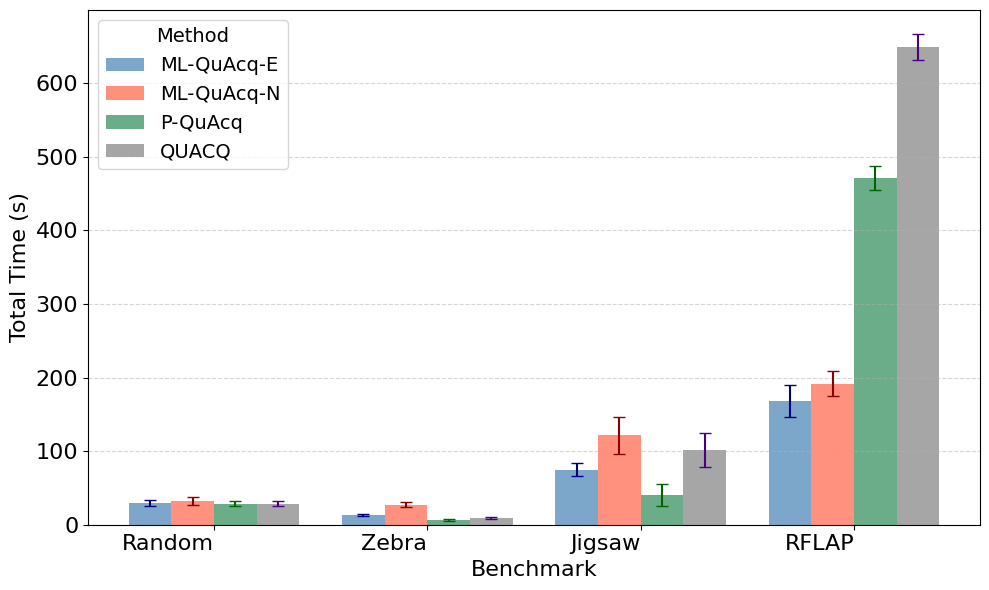

In [12]:
time_analysis = load_df(folder_path, "*")
time_analysis = time_analysis[(time_analysis['alpha'] == 4) | (time_analysis['method'] == 'quacq')]
time_analysis = time_analysis[['benchmark', 'method', 'seed', 'total_time']]

mean_std = time_analysis.groupby(['benchmark', 'method'])['total_time'].agg(['mean', 'std']).reset_index()

benchmark_order = ['random', 'zebra', 'jigsaw', 'rflap']
mean_std['benchmark'] = pd.Categorical(mean_std['benchmark'], categories=benchmark_order, ordered=True)
mean_std = mean_std.sort_values('benchmark')

benchmarks = benchmark_order
methods = mean_std['method'].unique()
x = np.arange(len(benchmarks))
bar_width = 0.2

colors = ['steelblue', 'tomato', 'seagreen', 'grey']
ecolors = ['navy', 'darkred', 'darkgreen', 'indigo']

fig, ax = plt.subplots(figsize=(10, 6))
LABEL_SIZE = 16
TICK_SIZE = 16
LEGEND_SIZE = 14

method_labels = {                          # <-- added
    'ml_quacq_n': 'ML-QuAcq-N',
    'ml_quacq_e': 'ML-QuAcq-E',
    'quacq':      'QUACQ',
    'pquacq':    'P-QuAcq'
}

for i, method in enumerate(methods):
    subset = mean_std[mean_std['method'] == method]
    ax.bar(x + i * bar_width, subset['mean'], bar_width,
           yerr=subset['std'], capsize=4,
           color=colors[i % len(colors)], alpha=0.7,
           label=method_labels.get(method, method),   # <-- changed
           error_kw=dict(ecolor=ecolors[i % len(ecolors)], linewidth=1.5))

ymin = mean_std['mean'].min()
ymax = mean_std['mean'].max()
ax.set_ylim(0, ymax + 50)

ax.set_xticks(x + bar_width * (len(methods) - 1) / 2)
ax.set_xticklabels(['Random', 'Zebra', 'Jigsaw', 'RFLAP'], ha='right', fontsize=TICK_SIZE)  # <-- changed
ax.tick_params(axis='y', labelsize=TICK_SIZE)

ax.set_xlabel('Benchmark', fontsize=LABEL_SIZE)
ax.set_ylabel('Total Time (s)', fontsize=LABEL_SIZE)

ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.legend(title='Method', loc='upper left', fontsize=LEGEND_SIZE, title_fontsize=LEGEND_SIZE)

plt.tight_layout()
plt.savefig('total_time_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

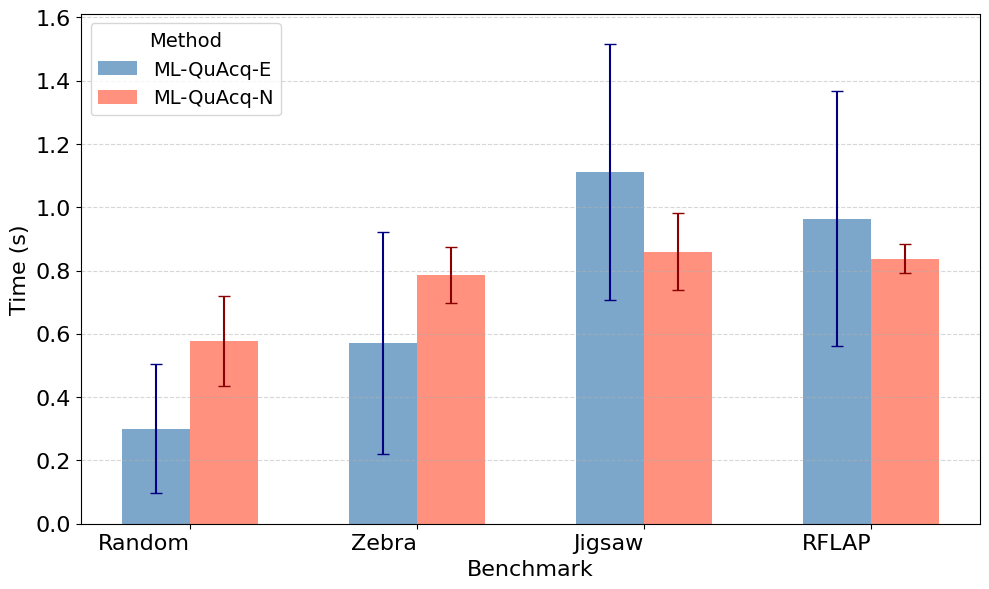

In [13]:
time_analysis = load_df(folder_path, "*_ml_quacq_*")
time_analysis = time_analysis[time_analysis['alpha'] == 4]
time_analysis = time_analysis[['benchmark', 'method', 'seed', 'time']]

mean_std = time_analysis.groupby(['benchmark', 'method'])['time'].agg(['mean', 'std']).reset_index()

benchmark_order = ['random', 'zebra', 'jigsaw', 'rflap']
mean_std['benchmark'] = pd.Categorical(mean_std['benchmark'], categories=benchmark_order, ordered=True)
mean_std = mean_std.sort_values('benchmark')

benchmarks = benchmark_order
methods = mean_std['method'].unique()
x = np.arange(len(benchmarks))
bar_width = 0.3

colors = ['steelblue', 'tomato', 'seagreen', 'mediumpurple']
ecolors = ['navy', 'darkred', 'darkgreen', 'indigo']

fig, ax = plt.subplots(figsize=(10, 6))

LABEL_SIZE = 16
TICK_SIZE = 16
LEGEND_SIZE = 14

# Map method names to display labels
method_labels = {
    'ml_quacq_n': 'ML-QuAcq-N',
    'ml_quacq_e': 'ML-QuAcq-E'
}
for i, method in enumerate(methods):
    subset = mean_std[mean_std['method'] == method]
    ax.bar(x + i * bar_width, subset['mean'], bar_width,
           yerr=subset['std'], capsize=4,
           color=colors[i % len(colors)], alpha=0.7, label=method_labels[method],  # <-- use mapped label
           error_kw=dict(ecolor=ecolors[i % len(ecolors)], linewidth=1.5))

ymin = mean_std['mean'].min()
ymax = mean_std['mean'].max()
ax.set_ylim(0, ymax + 0.5)

ax.set_xticks(x + bar_width * (len(methods) - 1) / 2)
ax.set_xticklabels(['Random', 'Zebra', 'Jigsaw', 'RFLAP'], ha='right', fontsize=TICK_SIZE)  # <-- benchmark fix
ax.tick_params(axis='y', labelsize=TICK_SIZE)

ax.set_xlabel('Benchmark', fontsize=LABEL_SIZE)
ax.set_ylabel('Time (s)', fontsize=LABEL_SIZE)

ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.legend(title='Method', loc='upper left', fontsize=LEGEND_SIZE, title_fontsize=LEGEND_SIZE)

plt.tight_layout()
plt.savefig('time_analysis_ml_quacq.png', dpi=300, bbox_inches='tight')
plt.show()

# Number of layer effect box plot

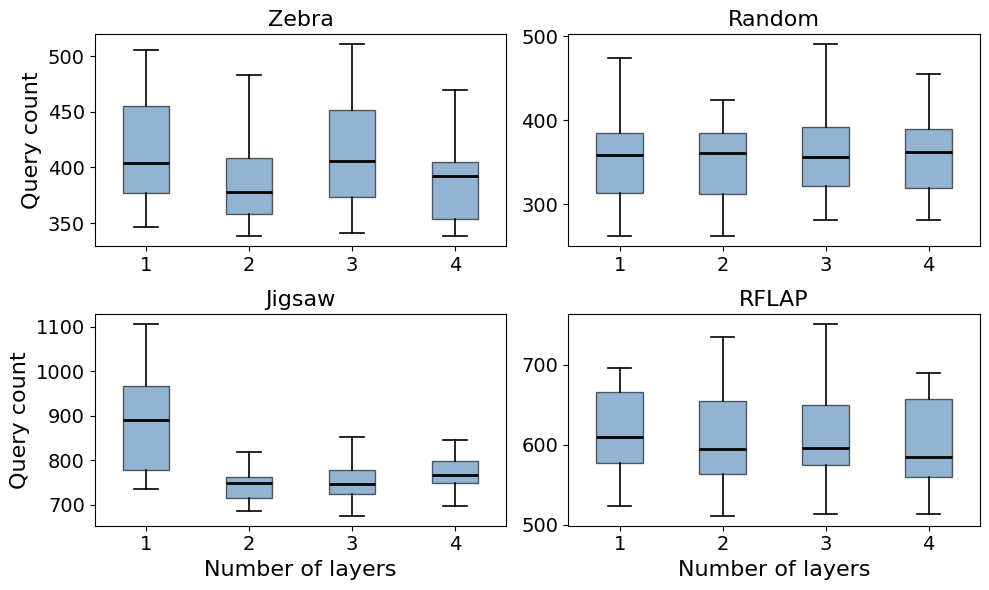

In [14]:
folder_path = "../../results/number_of_layer_effect"

LABEL_SIZE = 16
TICK_SIZE = 14
TITLE_SIZE = 16

zebra = load_df(folder_path, "zebra")
random = load_df(folder_path, "random")
jigsaw = load_df(folder_path, "jigsaw")
rflap = load_df(folder_path, "rflap")

fig, axes = plt.subplots(2, 2, figsize=(10, 6))

datasets = {
    "Zebra": zebra,
    "Random": random,
    "Jigsaw": jigsaw,
    "RFLAP": rflap
}


for idx, (ax, (name, df)) in enumerate(zip(axes.flatten(), datasets.items())):

    groups = [group["query"].values for _, group in df.groupby("num_layers")]
    labels = sorted(df["num_layers"].unique())

    ax.boxplot(groups, tick_labels=labels, patch_artist=True,
               showfliers=False,
               boxprops=dict(facecolor="steelblue", alpha=0.6),
               medianprops=dict(color="black", linewidth=2),
               whiskerprops=dict(linewidth=1.2),
               capprops=dict(linewidth=1.2))

    ax.set_title(name, fontsize=TITLE_SIZE)
    ax.tick_params(axis='both', labelsize=TICK_SIZE)

    if idx % 2 == 0:
        ax.set_ylabel("Query count", fontsize=LABEL_SIZE)
    else:
        ax.set_ylabel("")

    if idx >= 2:
        ax.set_xlabel("Number of layers", fontsize=LABEL_SIZE)
    else:
        ax.set_xlabel("")

plt.tight_layout()
plt.savefig("ablation_num_layers_starting.png", dpi=300, bbox_inches='tight')

# the cold start effect

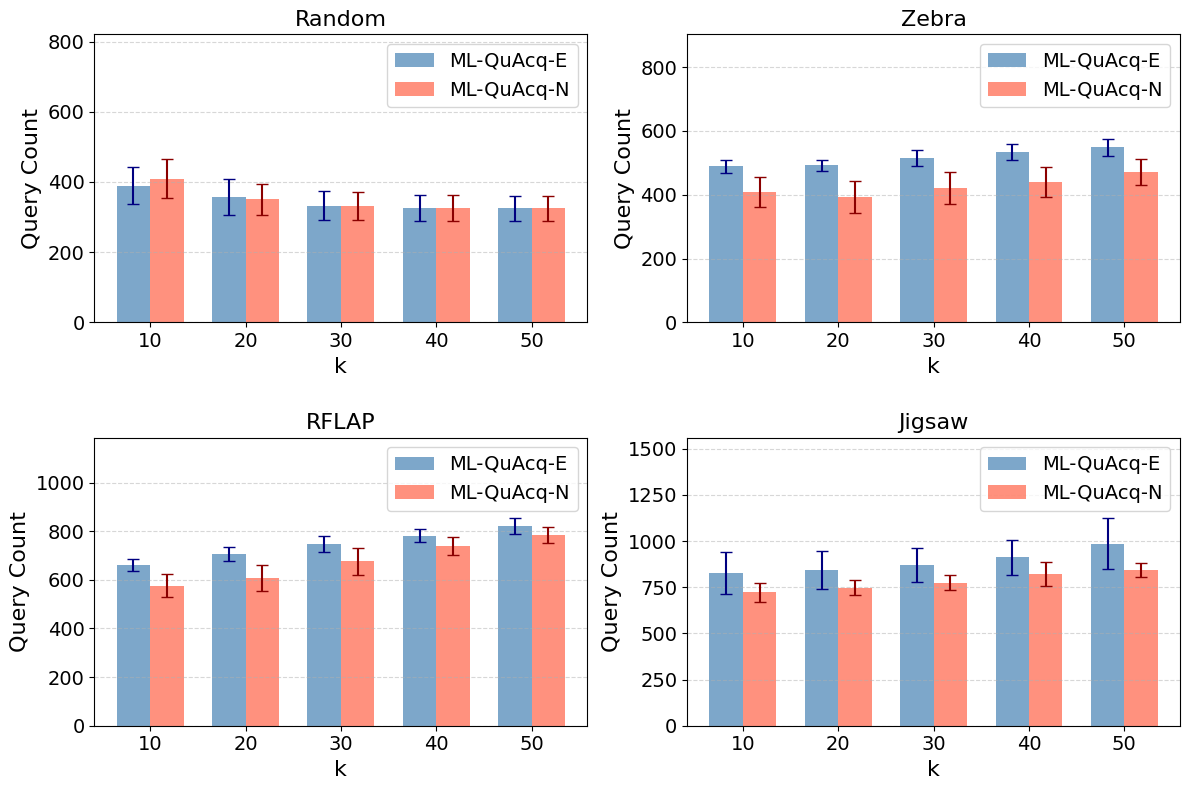

In [15]:
LABEL_SIZE = 16
TICK_SIZE = 14
TITLE_SIZE = 16
LEGEND_SIZE = 14

folder_path = "../../results/cold_start_results"
df = load_df(folder_path, "*_ml_quacq_*")
results = df.groupby(['benchmark', 'method', 'k'])['query'].agg(['mean', 'std']).reset_index()

benchmark_order = ['random', 'zebra', 'rflap', 'jigsaw']           # <-- changed order
benchmark_labels = {                                                 # <-- added
    'random': 'Random',
    'zebra':  'Zebra',
    'rflap':  'RFLAP',
    'jigsaw': 'Jigsaw'
}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, benchmark in enumerate(benchmark_order):                     # <-- changed
    ax = axes[i]

    bench_results = results[results['benchmark'] == benchmark].copy()
    edge_data = bench_results[bench_results['method'] == 'ml_quacq_e'].sort_values('k')
    node_data = bench_results[bench_results['method'] == 'ml_quacq_n'].sort_values('k')

    k_values = sorted(bench_results['k'].unique())
    x = np.arange(len(k_values))
    width = 0.35

    edge_data = edge_data.set_index('k').reindex(k_values)
    node_data = node_data.set_index('k').reindex(k_values)

    ax.bar(x - width / 2, edge_data['mean'], width,
           yerr=edge_data['std'].fillna(0), capsize=4,
           color='steelblue', alpha=0.7, label='ML-QuAcq-E',       # <-- changed
           error_kw=dict(ecolor='navy', linewidth=1.5))

    ax.bar(x + width / 2, node_data['mean'], width,
           yerr=node_data['std'].fillna(0), capsize=4,
           color='tomato', alpha=0.7, label='ML-QuAcq-N',          # <-- changed
           error_kw=dict(ecolor='darkred', linewidth=1.5))

    ymax = pd.concat([edge_data['mean']+ 2*edge_data['std'].fillna(0), node_data['mean']+2*node_data['std'].fillna(0)]).max()
   

    ax.set_ylim(0, ymax+300)

    ax.set_xticks(x)
    ax.set_xticklabels(k_values, fontsize=TICK_SIZE)
    ax.tick_params(axis='y', labelsize=TICK_SIZE)

    ax.set_xlabel('k', fontsize=LABEL_SIZE)
    ax.set_ylabel('Query Count', fontsize=LABEL_SIZE)
    ax.set_title(benchmark_labels[benchmark], fontsize=TITLE_SIZE)  # <-- changed
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.legend(loc='upper right', fontsize=LEGEND_SIZE, title_fontsize=LEGEND_SIZE)

for j in range(len(benchmark_order), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.savefig("cold_start.png", dpi=300)
plt.subplots_adjust(hspace=0.4)